In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.polynomial import Polynomial

Done


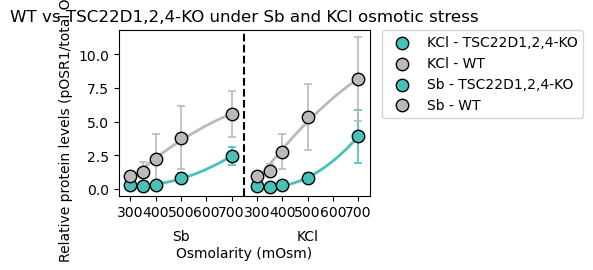

In [5]:
# Load CSV
df = pd.read_csv("Figure_2G_wt_vs_TSC22D1,2,4-KO_pOSR1_levels.csv")

# Colors
colors = {"WT": "#bababa", "TSC22D1,2,4-KO": "#49c1bb"}

# Shift KCl block to the right
shift = 500
df["Shifted_Osm"] = df.apply(
    lambda row: row["Osmolarity"] if row["Source"] == "Sb" else row["Osmolarity"] + shift,
    axis=1
)

# Create figure/axes
fig, ax = plt.subplots(figsize=(5.5, 3))

# Scatter + error bars + polynomial fit
for (source, cell_type), sub in df.groupby(["Source", "Cell"]):
    x = sub["Shifted_Osm"].values
    y = sub["Normalized_pSPAK-OSR1"].values
    err = sub["Error"].values

    # Error bars
    ax.errorbar(
        x, y,
        yerr=err,
        fmt="none",
        ecolor=colors[cell_type],
        elinewidth=1.2,
        capsize=3,
        capthick=1.2,
        zorder=2
    )

    # Scatter
    ax.scatter(
        x, y,
        color=colors[cell_type],
        edgecolor="black",
        s=80,
        marker="o",
        label=f"{source} - {cell_type}",
        zorder=3
    )

    # Polynomial fit (quadratic)
    p = Polynomial.fit(x, y, deg=2)
    xp = np.linspace(min(x), max(x), 200)
    yp = p(xp)
    ax.plot(xp, yp, color=colors[cell_type], lw=2, zorder=1)

# Divider between Sb and KCl
sb_max = df[df["Source"] == "Sb"]["Shifted_Osm"].max()
kcl_min = df[df["Source"] == "KCl"]["Shifted_Osm"].min()
divider = (sb_max + kcl_min) / 2
ax.axvline(divider, color="black", linestyle="--")

# X-ticks
sb_ticks = np.arange(300, 701, 100)
kcl_ticks = sb_ticks + shift
ax.set_xticks(np.concatenate([sb_ticks, kcl_ticks]))
ax.set_xticklabels([str(t) for t in sb_ticks] + [str(t) for t in sb_ticks])

# Group labels under x-axis
ymin, ymax = ax.get_ylim()
ax.text(sb_ticks.mean(), ymin - (ymax - ymin) * 0.2, "Sb", ha="center", va="top", fontsize=10)
ax.text(kcl_ticks.mean(), ymin - (ymax - ymin) * 0.2, "KCl", ha="center", va="top", fontsize=10)

# Labels and title
ax.set_ylabel("Relative protein levels (pOSR1/total OSR1)")
ax.set_xlabel("Osmolarity (mOsm)")
ax.set_title("WT vs TSC22D1,2,4-KO under Sb and KCl osmotic stress")
ax.xaxis.set_label_coords(0.5, -0.3)

# Legend outside right
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.savefig("Figure_2G_Dot_plot_wt_vs_TSC22D1,2,4-KO_pOSR1_levels.pdf",
            format="pdf", dpi=300, bbox_inches="tight", transparent=True)
print("Done")